1) Data Description:
players.csv contains 7 columns/variables: experience (Beginner, Amateur, Regular, Pro, and Veteran), subscribe (TRUE or FALSE), hashed email (string), played_hours (float), name (string), gender (Male, Female, Non-Binary, Prefer not to say, Agender, Two-Spirited, or Other), and Age (natural). Each row/observation represents a player and there are 196 of them. played_hours and Age have means of 5.90 and 21.14 respectively. Some issues I can see with the data are that there are some NAs and there are some outliers, such as people who have 0 hours played and others who have 200+ hours played. From the server sign up page I can see that they collected the data by asking people for their info when they signed up and also tracking their hours played.

2) Questions: I will address question 1: "What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?", specifically, can players' total play time and age predict whether or not they subscribe to a game-related newsletter? I will use the data to answer the question by plotting age vs. hours played and color coding the true and false points to reveal trends. From there, predictive analysis can be preformed. To wrangle this data I will only need to filter out the NA rows.

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
players <- read_csv("players.csv")

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
players_filtered <- players |>
    filter(!is.na(Age))

In [4]:
players_means <- players_filtered |>
    summarize(mean_played_hours = mean(played_hours, na.rm = TRUE),
              mean_age = mean(Age, na.rm = TRUE))

players_means

mean_played_hours,mean_age
<dbl>,<dbl>
5.904639,21.13918


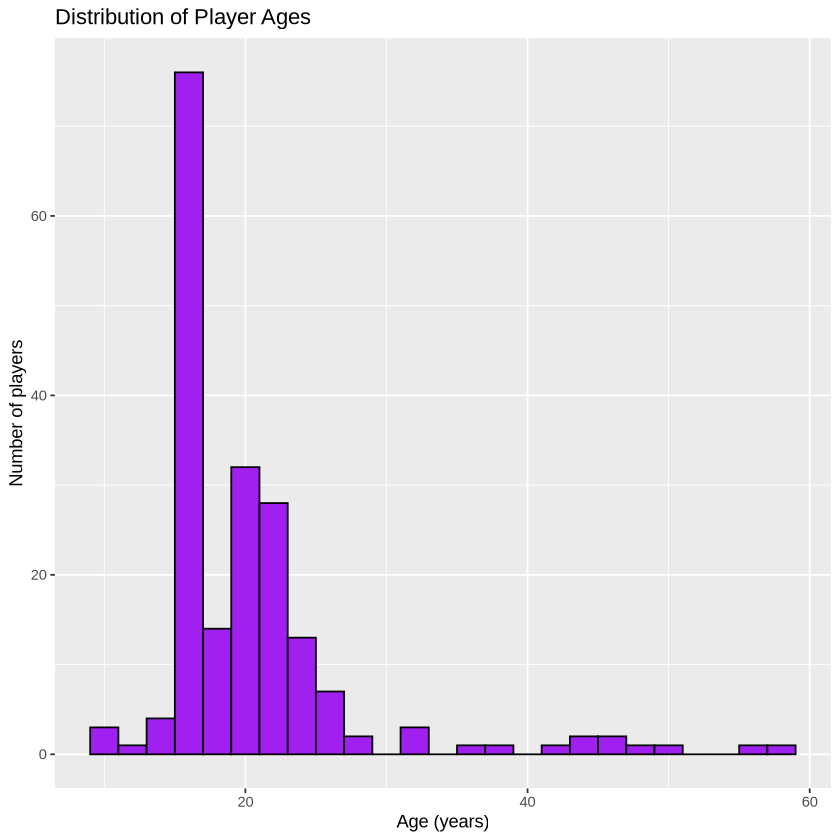

In [13]:
age_distribution <- ggplot(players_filtered, aes(x = Age)) +
    geom_histogram(binwidth = 2, fill = "purple", color = "black") +
    labs(title = "Distribution of Player Ages",
         x = "Age (years)",
         y = "Number of players")

age_distribution

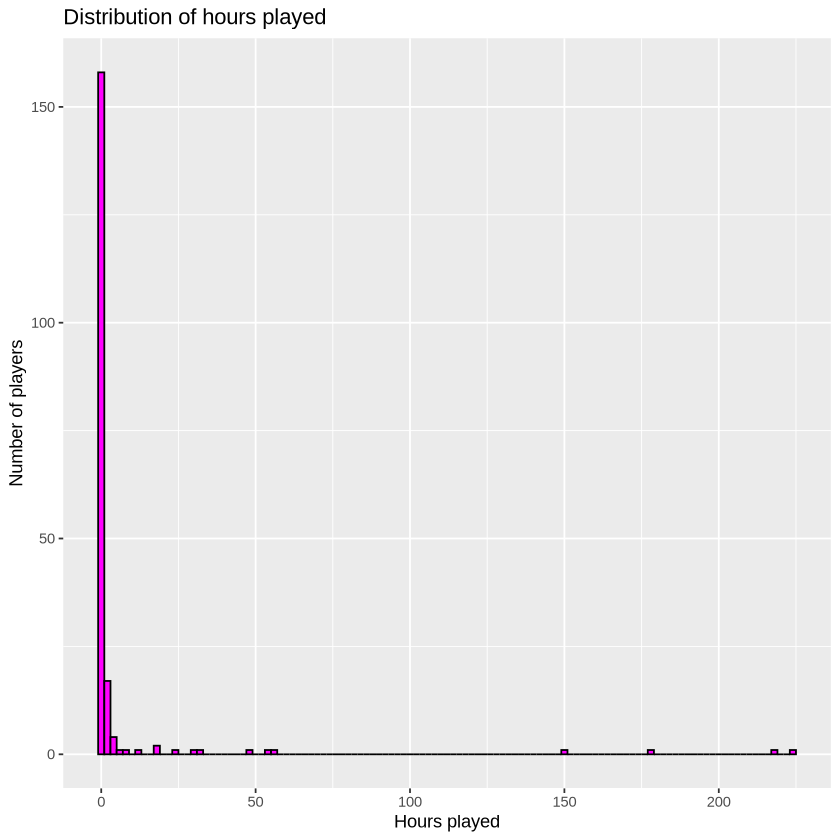

In [15]:
age_distribution <- ggplot(players_filtered, aes(x = played_hours)) +
    geom_histogram(binwidth = 2, fill = "magenta", color = "black") +
    labs(title = "Distribution of hours played",
         x = "Hours played",
         y = "Number of players")

age_distribution

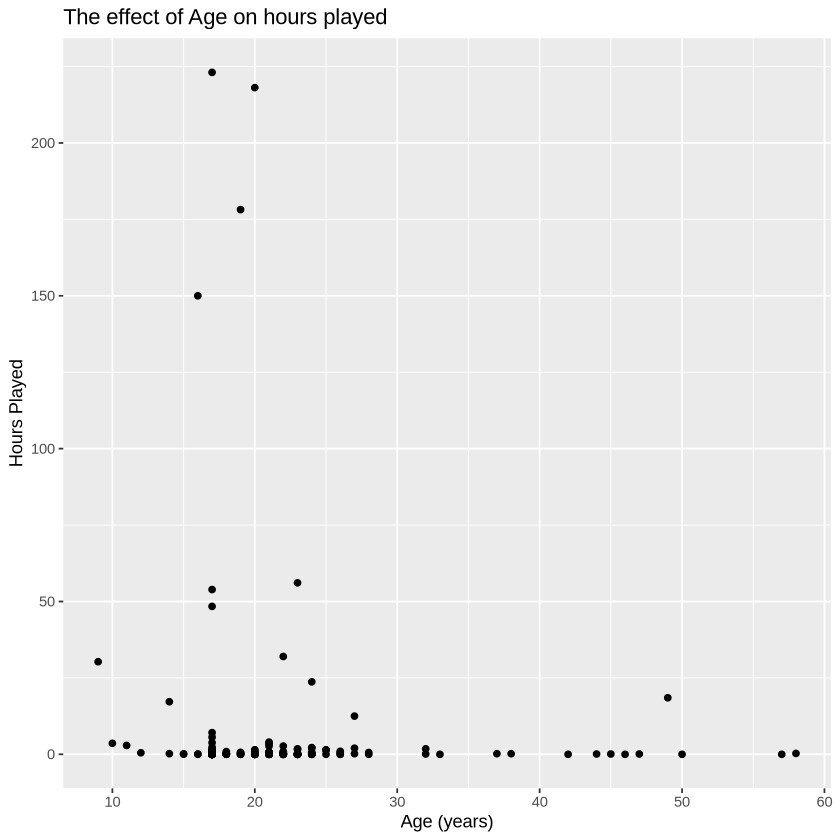

In [16]:
played_hrs_vs_age <- ggplot(players_filtered, aes(x = Age, y = played_hours)) +
    geom_point() +
    labs(title = "The effect of Age on hours played",
         x = "Age (years)",
         y = "Hours Played")

played_hrs_vs_age

3) Exploratory Data Analysis and Visualization: The two distributions above show us that player ages cluster around 20 and under while hours played cluster around 0 hours. The negative effects of these skewed distributions can be seen in the age vs. hours played plot, where a majority of the dots cluster at 0. Based on these visualizations, I would consider filtering out the 0 hour players so that we're able to better visualize any trends.

4) Methods and Plan: To address my question of "Can players' total play time and age predict whether or not they subscribe to a game-related newsletter?", I propose using the k-nearest neighbors classification method. This method is appropriate for the data I have because the true or false answer of whether or not a player has subscribed to the newsletter is binary and can act as the positive and negative classification of a point. To preform k-nn, it must be assumed that the data is scaled correctly, i.e. hours played doesn't have a bigger impact on the prediction than age simply because it has a larger range of numbers. K-nn's weaknesses are that it is sensitive to outliers, and it takes a lot of tuning to find the best k value to use. After filtering out outliers and standardizing the data, it will be split into a training set with 70% of the observations, and a testing set with 30% of the observations. Then, the training data will be split into 5 folds to preform cross-validation and find the best k value. Applying the best k value to our test set, hopefully the model's predictions are accurate.